IMPORTING LIBARARIES


In [1]:
import gymnasium
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


CREATING HOME ENERGY MANAGEMENT ENVIRONMENT


In [2]:
class HEMSEnv(gymnasium.Env):
    """Home Energy Management System Environment."""
    metadata = {"render.modes": ["human"]}

    def __init__(self):
        super(HEMSEnv, self).__init__()

        # State and Action spaces
        self.max_battery = 5.0
        self.battery_soc = 2.5
        self.action_space = spaces.Discrete(4)  # 0: Solar, 1: Battery, 2: UPS, 3: Grid
        self.observation_space = spaces.Box(low=0, high=1, shape=(5,), dtype=np.float32)

        self.time_step = 0
        self.max_time = 24

    def _get_state(self):
        """Construct the state vector."""
        return np.array([
            self.time_step / 24,
            self.battery_soc / self.max_battery,
            self.solar_output / 5.0,
            self.load_demand / 5.0,
            self.ups_status
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        """Reset environment state and return initial state and info."""
        self.battery_soc = 2.5
        self.time_step = 0
        self.ups_status = 1
        self.solar_output = 0
        self.load_demand = 2
        return self._get_state(), {}  # ✅ Returns (state, info)

    def step(self, action):
        """Perform one environment step given an action."""
        self.solar_output = max(0, 5 * np.sin(np.pi * self.time_step / 24))
        self.load_demand = 2 + np.random.rand()
        self.ups_status = 1 if self.battery_soc > 3.0 else 0

        reward = 0
        cost = 0

        if action == 0:  # Use Solar
            if self.solar_output >= self.load_demand:
                reward = 1
            else:
                cost = (self.load_demand - self.solar_output) * 0.3
        elif action == 1:  # Use Battery
            if self.battery_soc >= self.load_demand:
                self.battery_soc -= self.load_demand
                reward = 0.5
            else:
                cost = (self.load_demand - self.battery_soc) * 0.3
                self.battery_soc = 0
        elif action == 2:  # Use UPS
            if self.ups_status:
                reward = 0.8
            else:
                cost = self.load_demand * 0.5
        elif action == 3:  # Use Grid
            cost = self.load_demand * 0.6

        reward -= cost
        self.time_step += 1
        terminated = self.time_step >= self.max_time
        truncated = False
        info = {}

        return self._get_state(), reward, terminated, truncated, info


In [3]:
env = HEMSEnv()
state, info = env.reset()
print("Initial State:", state)

log = defaultdict(list)

for t in range(24):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)

    log['time'].append(t)
    log['solar'].append(state[2] * 5)
    log['load'].append(state[3] * 5)
    log['battery_soc'].append(state[1] * env.max_battery)
    log['reward'].append(reward)
    log['action'].append(action)

    state = next_state
    if terminated or truncated:
        break


Initial State: [0.  0.5 0.  0.4 1. ]


TESTING AND VISUALIZING THE ENVIRONMENT


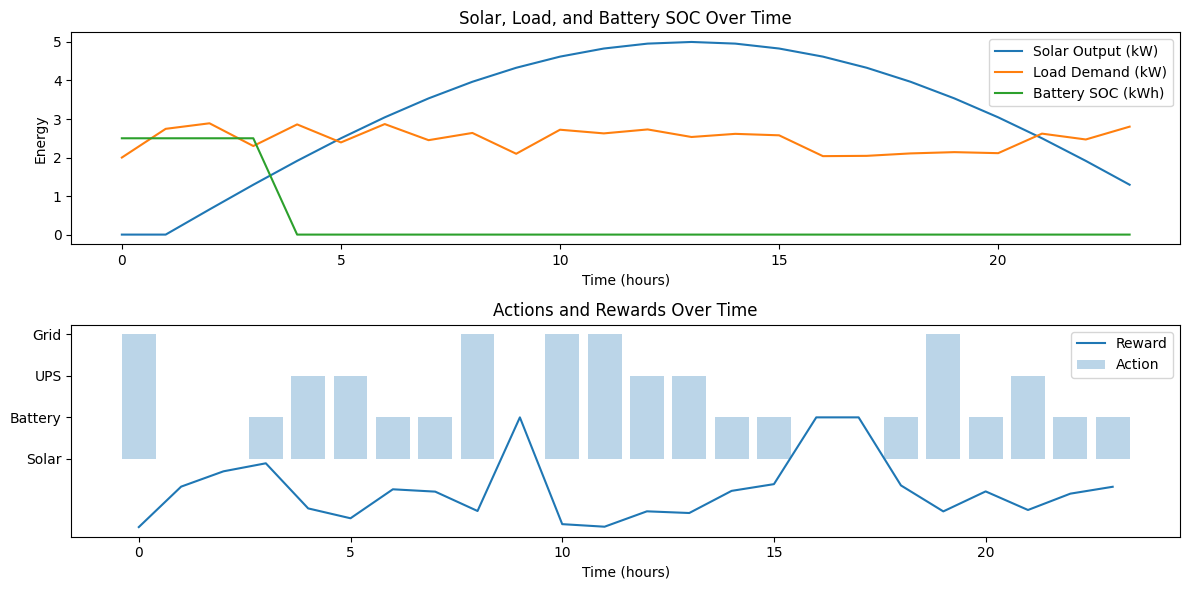

In [4]:
plt.figure(figsize=(12, 6))

# Plot 1: Energy dynamics
plt.subplot(2, 1, 1)
plt.plot(log['time'], log['solar'], label='Solar Output (kW)')
plt.plot(log['time'], log['load'], label='Load Demand (kW)')
plt.plot(log['time'], log['battery_soc'], label='Battery SOC (kWh)')
plt.title('Solar, Load, and Battery SOC Over Time')
plt.xlabel('Time (hours)')
plt.ylabel('Energy')
plt.legend()

# Plot 2: Action and Reward
plt.subplot(2, 1, 2)
plt.plot(log['time'], log['reward'], label='Reward')
plt.bar(log['time'], log['action'], label='Action', alpha=0.3)
plt.yticks([0, 1, 2, 3], ['Solar', 'Battery', 'UPS', 'Grid'])
plt.title('Actions and Rewards Over Time')
plt.xlabel('Time (hours)')
plt.legend()
plt.tight_layout()
plt.show()


PPO RL Agent Setup


In [5]:
import gymnasium
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv

# 1️⃣ Import or define HEMSEnv above this point

# 2️⃣ Validate the environment
env = HEMSEnv()
check_env(env)

# 3️⃣ Wrap in DummyVecEnv
vec_env = DummyVecEnv([lambda: HEMSEnv()])

# 4️⃣ Train the agent
model = PPO("MlpPolicy", vec_env, verbose=1)
model.learn(total_timesteps=50000)

# 5️⃣ Save the trained model
model.save("ppo_hems_agent")

# 6️⃣ Load the model
model = PPO.load("ppo_hems_agent")

# 7️⃣ Test the trained model
state, info = env.reset()
terminated = False
truncated = False

while not (terminated or truncated):
    action, _ = model.predict(state)  # Get action
    state, reward, terminated, truncated, info = env.step(action)  # New-style step
    print(f"Action: {action}, Reward: {reward:.2f}")



Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2763 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1427        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.020482041 |
|    clip_fraction        | 0.315       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.37       |
|    explained_variance   | -0.00385    |
|    learning_rate        | 0.0003      |
|    loss                 | 3.01        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0369     |
|    value_loss           | 15.3        |
-----------------------------------------
-----------------

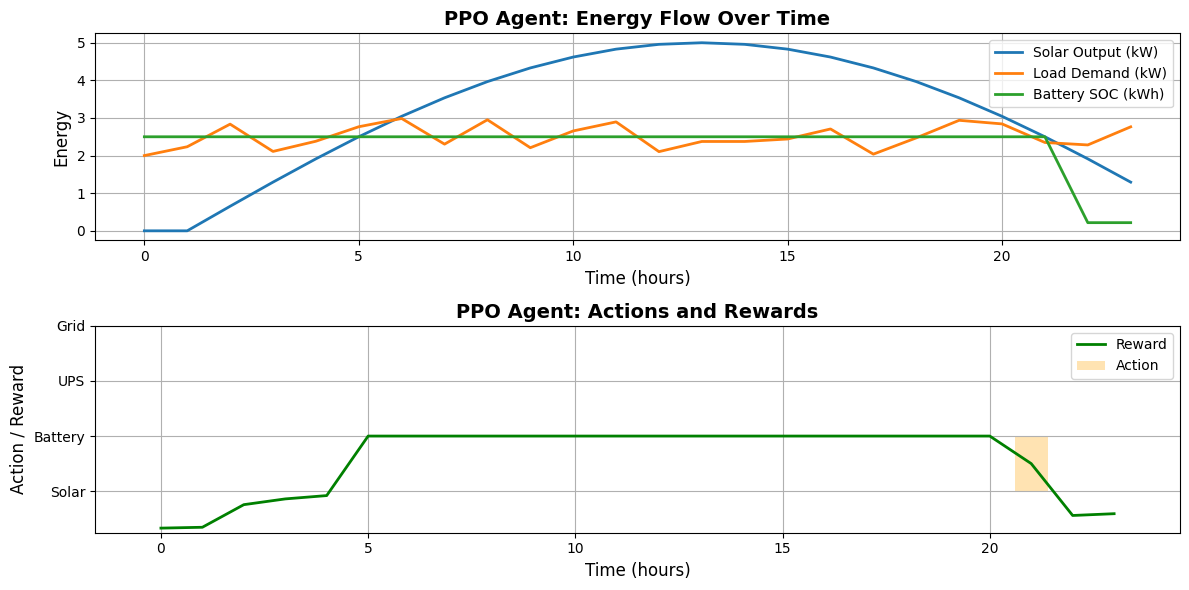

In [6]:
import matplotlib.pyplot as plt
from collections import defaultdict
from stable_baselines3 import PPO

# 1️⃣ Load trained model and initialize environment
model = PPO.load("ppo_hems_agent")
env = HEMSEnv()
state, _ = env.reset()  # ✅ New-style reset
log = defaultdict(list)

t = 0
terminated = False
truncated = False

# 2️⃣ Run the trained agent
while not (terminated or truncated):
    action, _ = model.predict(state)
    next_state, reward, terminated, truncated, info = env.step(action)

    # 3️⃣ Log values
    log["time"].append(t)
    log["solar"].append(state[2] * 5)           # State scaled solar
    log["load"].append(state[3] * 5)            # State scaled load
    log["battery_soc"].append(state[1] * env.max_battery)  # State scaled battery
    log["reward"].append(reward)
    log["action"].append(action)

    state = next_state
    t += 1

# 4️⃣ Plot Results
plt.figure(figsize=(12, 6))

# ---- Subplot 1 ----
plt.subplot(2, 1, 1)
plt.plot(log["time"], log["solar"], label="Solar Output (kW)", linewidth=2)
plt.plot(log["time"], log["load"], label="Load Demand (kW)", linewidth=2)
plt.plot(log["time"], log["battery_soc"], label="Battery SOC (kWh)", linewidth=2)
plt.title("PPO Agent: Energy Flow Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Time (hours)", fontsize=12)
plt.ylabel("Energy", fontsize=12)
plt.legend()
plt.grid(True)

# ---- Subplot 2 ----
plt.subplot(2, 1, 2)
plt.plot(log["time"], log["reward"], label="Reward", color="green", linewidth=2)
plt.bar(log["time"], log["action"], label="Action", alpha=0.3, color="orange")
plt.yticks([0, 1, 2, 3], ["Solar", "Battery", "UPS", "Grid"])
plt.title("PPO Agent: Actions and Rewards", fontsize=14, fontweight="bold")
plt.xlabel("Time (hours)", fontsize=12)
plt.ylabel("Action / Reward", fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



Log Cost Savings and UPS Usage Metrics


In [7]:
from collections import defaultdict
import numpy as np
from stable_baselines3 import PPO

# 1️⃣ Load Model and Init Env
model = PPO.load("ppo_hems_agent")
env = HEMSEnv()
state, _ = env.reset()

# 2️⃣ Initialize Metrics
metrics = {
    "cost": 0.0,
    "source_use": {"solar": 0, "battery": 0, "ups": 0, "grid": 0},
    "energy_from": {"solar": 0.0, "battery": 0.0, "ups": 0.0, "grid": 0.0}
}

# 3️⃣ Simulation Loop
terminated = False
truncated = False
t = 0

while not (terminated or truncated):
    action, _ = model.predict(state)
    solar = state[2] * 5
    demand = state[3] * 5
    soc = state[1] * env.max_battery

    # Perform manual cost/supply calculations
    if action == 0:  # Solar
        supplied = min(solar, demand)
        shortfall = demand - supplied
        cost = shortfall * 0.3
        metrics["source_use"]["solar"] += 1
        metrics["energy_from"]["solar"] += supplied

    elif action == 1:  # Battery
        supplied = min(soc, demand)
        shortfall = demand - supplied
        cost = shortfall * 0.3
        metrics["source_use"]["battery"] += 1
        metrics["energy_from"]["battery"] += supplied

    elif action == 2:  # UPS
        if soc > 3:
            supplied = demand
            cost = 0
            metrics["source_use"]["ups"] += 1
            metrics["energy_from"]["ups"] += supplied
        else:
            supplied = 0
            cost = demand * 0.5
            metrics["source_use"]["ups"] += 1

    elif action == 3:  # Grid
        supplied = demand
        cost = demand * 0.6
        metrics["source_use"]["grid"] += 1
        metrics["energy_from"]["grid"] += supplied

    metrics["cost"] += cost

    # ✅ Perform actual environment step
    state, _, terminated, truncated, info = env.step(action)

    t += 1

# 4️⃣ Final Results
print("\n📊 PPO Agent Performance Summary:", end="\n-----------------------------\n")
print(f"Total Cost: ${metrics['cost']:.2f}")

for src in metrics["source_use"]:
    times_used = metrics["source_use"][src]
    total_energy = metrics["energy_from"][src]
    print(f"{src.title():<8} Used: {times_used:2d} times | Energy Supplied: {total_energy:.2f} kWh")



📊 PPO Agent Performance Summary:
-----------------------------
Total Cost: $3.18
Solar    Used: 22 times | Energy Supplied: 45.24 kWh
Battery  Used:  2 times | Energy Supplied: 2.74 kWh
Ups      Used:  0 times | Energy Supplied: 0.00 kWh
Grid     Used:  0 times | Energy Supplied: 0.00 kWh
